PROJECT ONE DATA VISUALIZATION
DDA-01-0002/2024

In [7]:
"""loading the dataset"""
import pandas as pd
df=pd.read_csv("C:\\Users\\ADMIN\\Downloads\\employee_salary_data.csv")
df

,Employee_ID,Age,Gender,Education_Level,Work_Experience,Job_Title,Department,Monthly_Salary,Performance_Score,Remote_Work_Percentage,City
0,1001,50,Male,Bachelor,9,Manager,Marketing,80000.0,8,25,Nakuru
1,1002,36,Female,Bachelor,16,Data Scientist,Operations,69000.0,9,25,Eldoret
2,1003,29,Female,Bachelor,9,Analyst,Marketing,48000.0,3,0,Kisumu
3,1004,42,Female,Bachelor,16,Consultant,Finance,91000.0,10,0,Kisumu
4,1005,40,Female,Bachelor,19,Manager,Finance,64000.0,3,25,Nairobi
...,...,...,...,...,...,...,...,...,...,...,...
195,1196,40,Male,Master,20,Analyst,HR,88000.0,10,0,Mombasa
196,1197,41,Female,Bachelor,36,Consultant,Operations,69000.0,7,0,Nairobi
197,1198,53,Male,Bachelor,4,Engineer,Operations,78000.0,5,25,Mombasa
198,1199,28,Female,Bachelor,18,Consultant,Finance,54000.0,3,0,Eldoret


displaying first 5 columns

In [6]:

df.head()

,Employee_ID,Age,Gender,Education_Level,Work_Experience,Job_Title,Department,Monthly_Salary,Performance_Score,Remote_Work_Percentage,City
0,1001,50,Male,Bachelor,9,Manager,Marketing,80000.0,8,25,Nakuru
1,1002,36,Female,Bachelor,16,Data Scientist,Operations,69000.0,9,25,Eldoret
2,1003,29,Female,Bachelor,9,Analyst,Marketing,48000.0,3,0,Kisumu
3,1004,42,Female,Bachelor,16,Consultant,Finance,91000.0,10,0,Kisumu
4,1005,40,Female,Bachelor,19,Manager,Finance,64000.0,3,25,Nairobi


#checking for null values

In [10]:
##no  null values
df.isnull().sum().sum()

0

checking duplicates

In [14]:
#no duplicates
df.duplicated().sum()

0

Converting categorical variables 

In [74]:
# Step 1: Identifying categorical variables
categorical_vars = ['Job_Title', 'Education_Level','Department']

# Step 2: Convert categorical variables

# Option A: One-Hot Encoding
df_one_hot = pd.get_dummies(df, columns=categorical_vars, drop_first=True)
print("One-Hot Encoded DataFrame:")
print(df_one_hot)

One-Hot Encoded DataFrame:
     Employee_ID  Age  Gender  Work_Experience  Monthly_Salary  \
0           1001   50    Male                9         80000.0   
1           1002   36  Female               16         69000.0   
2           1003   29  Female                9         48000.0   
3           1004   42  Female               16         91000.0   
4           1005   40  Female               19         64000.0   
..           ...  ...     ...              ...             ...   
195         1196   40    Male               20         88000.0   
196         1197   41  Female               36         69000.0   
197         1198   53    Male                4         78000.0   
198         1199   28  Female               18         54000.0   
199         1200   54    Male               13        104000.0   

     Performance_Score  Remote_Work_Percentage     City  Job_Title_Consultant  \
0                    8                      25   Nakuru                 False   
1                 

<Axes: ylabel='Monthly_Salary'>

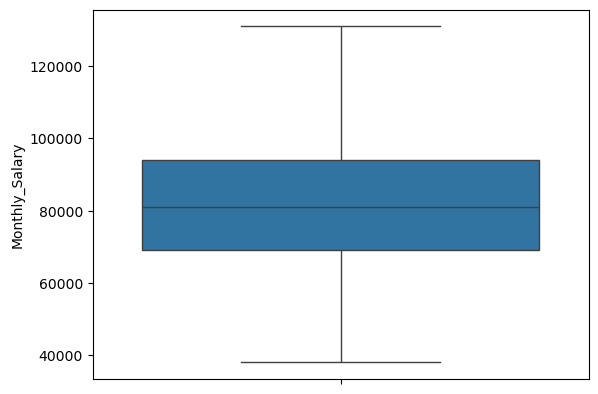

In [54]:
##identifying outliers and handling them 
import seaborn as sns
sns.boxplot(data =df,y=df['Monthly_Salary'])

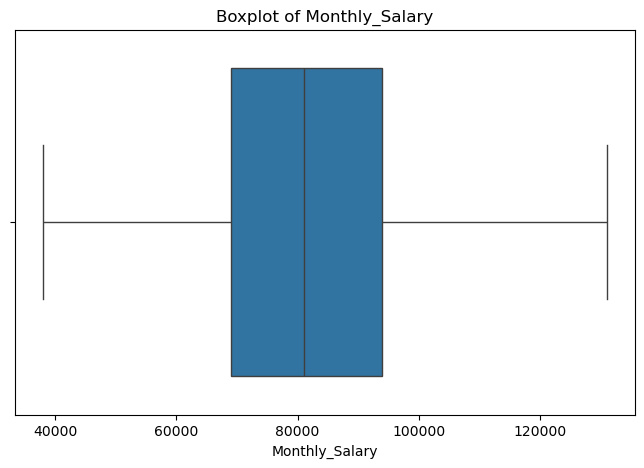

Identified Outliers:
Empty DataFrame
Columns: [Employee_ID, Age, Gender, Education_Level, Work_Experience, Job_Title, Department, Monthly_Salary, Performance_Score, Remote_Work_Percentage, City]
Index: []

Data after removing outliers:
     Employee_ID  Age  Gender Education_Level  Work_Experience  \
0           1001   50    Male        Bachelor                9   
1           1002   36  Female        Bachelor               16   
2           1003   29  Female        Bachelor                9   
3           1004   42  Female        Bachelor               16   
4           1005   40  Female        Bachelor               19   
..           ...  ...     ...             ...              ...   
195         1196   40    Male          Master               20   
196         1197   41  Female        Bachelor               36   
197         1198   53    Male        Bachelor                4   
198         1199   28  Female        Bachelor               18   
199         1200   54    Male         

In [58]:


# Step 2: Visualize the data using a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Monthly_Salary'])
plt.title('Boxplot of Monthly_Salary')
plt.show()

# Step 3: Identify outliers using IQR method
Q1 = df['Monthly_Salary'].quantile(0.25)
Q3 = df['Monthly_Salary'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Monthly_Salary'] < lower_bound) | (df['Monthly_Salary'] > upper_bound)]
print("Identified Outliers:")
print(outliers)

# Step 4: Handle outliers
# Option A: Remove outliers
df_no_outliers = df[(df['Monthly_Salary'] >= lower_bound) & (df['Monthly_Salary'] <= upper_bound)]
print("\nData after removing outliers:")
print(df_no_outliers)

# Option B: Capping outliers (if you prefer not to remove them)
df['Monthly_Salary'] = df['Monthly_Salary'].clip(lower=lower_bound, upper=upper_bound)
print("\nData after capping outliers:")
print(df)

In [72]:
from matplotlib import pyplot as plt

In [119]:
avg_salaries=df.groupby('Department')['Monthly_Salary'].mean()


In [123]:
Departments=avg_salaries.index
average_salaries=avg_salaries.values

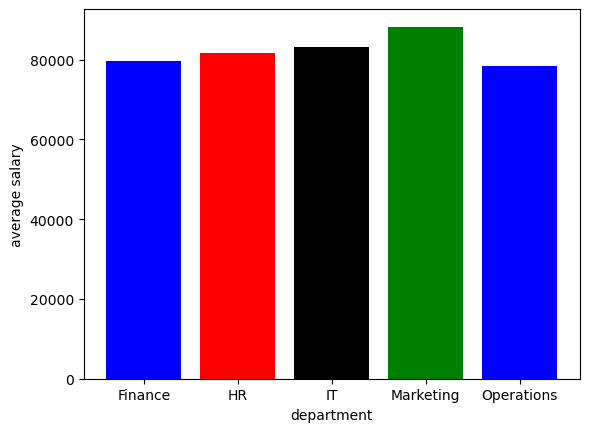

In [131]:
plt.bar(Departments,average_salaries,color=['blue','red','black','green'])
plt.ylabel('average salary')
plt.xlabel('department')
plt.show()

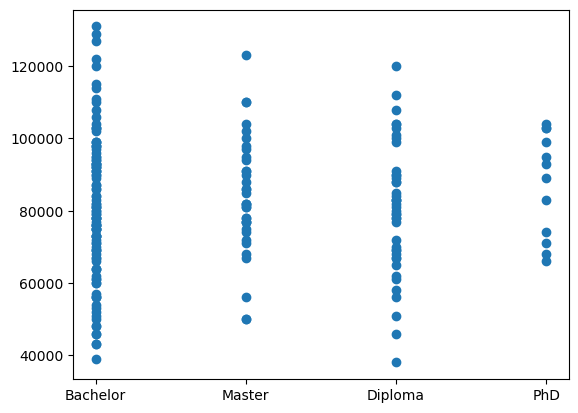

In [159]:
##How does education level affect salary? Create a visualization to support your answer
plt.scatter(df['Education_Level'],df['Monthly_Salary'])

Is there a correlation between work experience and monthly salary? Use a scatter plot to visualize.

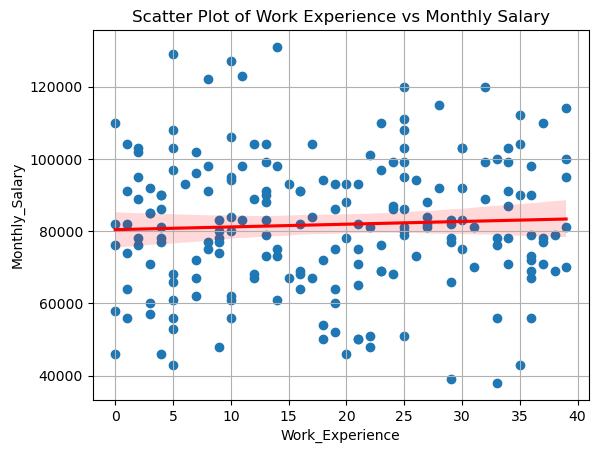

In [78]:
plt.scatter(df['Work_Experience'],df['Monthly_Salary'])
"""Add a regression line to visualize the trend"""
sns.regplot(x='Work_Experience', y='Monthly_Salary', data=df, scatter=False, color='red')

# Add titles and labels
plt.title('Scatter Plot of Work Experience vs Monthly Salary')
plt.xlabel('Work_Experience')
plt.ylabel('Monthly_Salary')
plt.grid(True)
plt.show()

In [71]:
##Does gender impact salary? Compare average salaries for each gender.
avg_salaries=df.groupby('Gender')['Monthly_Salary'].mean()

In [72]:
avg_salaries

Gender
Female    83239.130435
Male      79229.166667
Other     90833.333333
Name: Monthly_Salary, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x2676d1bb650>,
 'caps': [<matplotlib.lines.Line2D at 0x2676d398650>,
 'boxes': [<matplotlib.lines.Line2D at 0x2676d35fef0>,
 'medians': [<matplotlib.lines.Line2D at 0x2676d398c20>,
 'fliers': [<matplotlib.lines.Line2D at 0x2676d398e90>,
 'means': []}

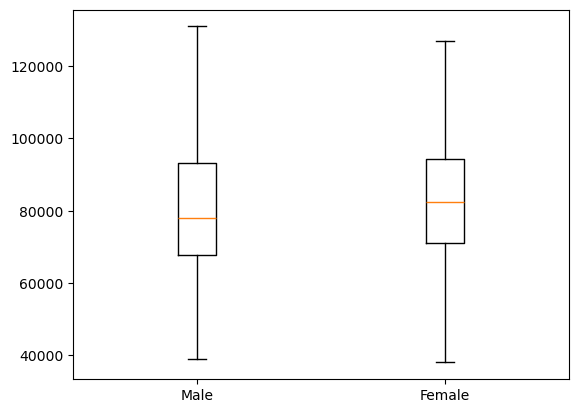

In [165]:
plt.boxplot([df[df['Gender']=='Male']['Monthly_Salary'],df[df['Gender']=='Female']['Monthly_Salary']],labels=['Male','Female'])

In [4]:
df_Gender = pd.get_dummies(df['Gender'])
df_new = pd.concat([df, df_Gender], axis=1)
print(df_new)


     Employee_ID  Age  Gender Education_Level  Work_Experience  \
0           1001   50    Male        Bachelor                9   
1           1002   36  Female        Bachelor               16   
2           1003   29  Female        Bachelor                9   
3           1004   42  Female        Bachelor               16   
4           1005   40  Female        Bachelor               19   
..           ...  ...     ...             ...              ...   
195         1196   40    Male          Master               20   
196         1197   41  Female        Bachelor               36   
197         1198   53    Male        Bachelor                4   
198         1199   28  Female        Bachelor               18   
199         1200   54    Male          Master               13   

          Job_Title  Department  Monthly_Salary  Performance_Score  \
0           Manager   Marketing         80000.0                  8   
1    Data Scientist  Operations         69000.0                  9 

In [68]:
##Which department has the highest proportion of remote workers?
df.groupby('Department')['Remote_Work_Percentage'].describe()

,count,mean,std,min,25%,50%,75%,max
Department,,,,,,,,
Finance,50.0,27.500000,29.987242,0.0,0.0,25.0,50.00,100.0
HR,40.0,23.750000,26.524058,0.0,0.0,25.0,31.25,100.0
IT,39.0,16.025641,24.660310,0.0,0.0,0.0,25.00,75.0
Marketing,31.0,22.580645,29.122470,0.0,0.0,0.0,37.50,100.0
Operations,40.0,23.750000,29.930475,0.0,0.0,25.0,25.00,100.0


In [226]:
df.Department

0       Marketing
1      Operations
2       Marketing
3         Finance
4         Finance
          ...    
195            HR
196    Operations
197    Operations
198       Finance
199            HR
Name: Department, Length: 200, dtype: object

In [232]:
high_dep= df.loc[df['Remote_Work_Percentage'].idxmax()]

In [234]:
high_dep

Employee_ID                   1011
Age                             45
Gender                       Other
Education_Level           Bachelor
Work_Experience                 12
Job_Title                  Analyst
Department                 Finance
Monthly_Salary             89000.0
Performance_Score                5
Remote_Work_Percentage         100
City                       Mombasa
avg_sal                    81770.0
mean                       81770.0
remote_per                     100
highest_per                    100
Name: 10, dtype: object

performing anova test

In [5]:
"""importing relevant libraries"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [13]:
df

,Employee_ID,Age,Gender,Education_Level,Work_Experience,Job_Title,Department,Monthly_Salary,Performance_Score,Remote_Work_Percentage,City
0,1001,50,Male,Bachelor,9,Manager,Marketing,80000.0,8,25,Nakuru
1,1002,36,Female,Bachelor,16,Data Scientist,Operations,69000.0,9,25,Eldoret
2,1003,29,Female,Bachelor,9,Analyst,Marketing,48000.0,3,0,Kisumu
3,1004,42,Female,Bachelor,16,Consultant,Finance,91000.0,10,0,Kisumu
4,1005,40,Female,Bachelor,19,Manager,Finance,64000.0,3,25,Nairobi
...,...,...,...,...,...,...,...,...,...,...,...
195,1196,40,Male,Master,20,Analyst,HR,88000.0,10,0,Mombasa
196,1197,41,Female,Bachelor,36,Consultant,Operations,69000.0,7,0,Nairobi
197,1198,53,Male,Bachelor,4,Engineer,Operations,78000.0,5,25,Mombasa
198,1199,28,Female,Bachelor,18,Consultant,Finance,54000.0,3,0,Eldoret


ANOVA for Work Experience

In [8]:
model_we = ols('Monthly_Salary ~ C(Work_Experience)', data=df).fit()
anova_table_we = sm.stats.anova_lm(model_we, typ=2)
print("ANOVA results for Work Experience:")
print(anova_table_we)


ANOVA results for Work Experience:
                          sum_sq     df         F    PR(>F)
C(Work_Experience)  1.432423e+10   39.0  1.072741  0.370544
Residual            5.478119e+10  160.0       NaN       NaN


ANOVA for Education Level

In [10]:

model_el = ols('Monthly_Salary ~ C(Education_Level)', data=df).fit()
anova_table_el = sm.stats.anova_lm(model_el, typ=2)
print("\nANOVA results for Education Level:")
print(anova_table_el)



ANOVA results for Education Level:
                          sum_sq     df         F    PR(>F)
C(Education_Level)  7.264758e+08    3.0  0.694118  0.556653
Residual            6.837894e+10  196.0       NaN       NaN


ANOVA for Interaction Effect

In [17]:

model_interaction = ols('Monthly_Salary ~ C(Work_Experience) * C(Education_Level)', data=df).fit()
anova_table_interaction = sm.stats.anova_lm(model_interaction, typ=2)
print("\nANOVA results for Interaction Effect:")
print(anova_table_interaction)



ANOVA results for Interaction Effect:
                                             sum_sq     df             F  \
C(Work_Experience)                     1.697569e+10   39.0  1.229475e+00   
C(Education_Level)                     2.113892e-01    3.0  1.990299e-10   
C(Work_Experience):C(Education_Level)  3.687191e+10  117.0  8.901568e-01   
Residual                               3.469519e+10   98.0           NaN   

                                         PR(>F)  
C(Work_Experience)                     0.281992  
C(Education_Level)                     0.999989  
C(Work_Experience):C(Education_Level)  0.686458  
Residual                                    NaN  


boxplot showing distribution of diff job titles

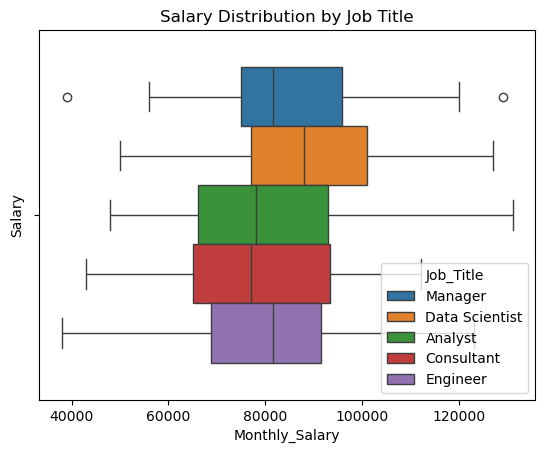

In [57]:
sns.boxplot(x=df['Monthly_Salary'],data=df,hue='Job_Title' )
plt.title('Salary Distribution by Job Title')
plt.ylabel('Salary')
plt.show()

Develop a heatmap to visualize correlations among numeric variables.

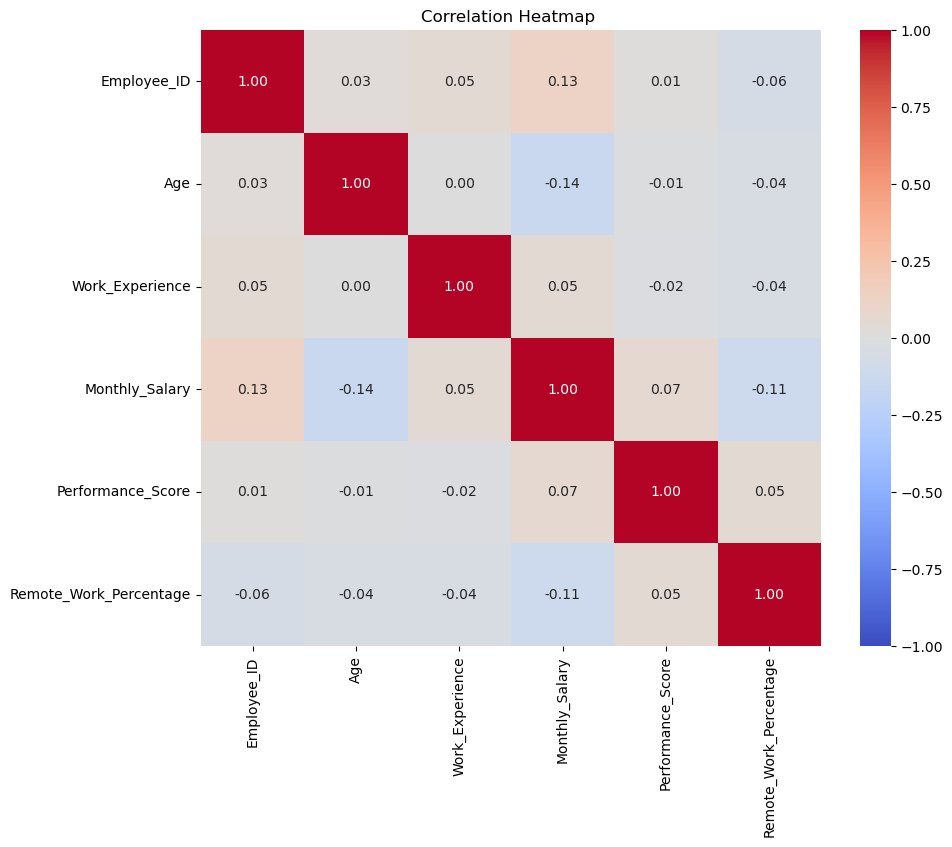

In [86]:
numerical_columns=df.select_dtypes("number")

# Calculate the correlation matrix
corr_matrix = numerical_columns.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))  # Set the figure size
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)

# Add titles and labels
plt.title('Correlation Heatmap ')
plt.show()

the key factors that influence salary levels in the dataset

In [67]:
print("Age","Education levels","Gender")

Age Education levels Gender


In [ ]:
##insights that  HR can use to improve salary structures and hiring policies
Market Analysis: Regularly analyze salaries for similar positions in other organizations to stay competitive
HR should recogonize that salary often increases with experience
HR should aslo
